### **Trader Behavior vs Market Sentiment Analysis**

### Data Loading

In [25]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [26]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [27]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Data Understanding

In [28]:
sentiment.shape

(2644, 4)

In [29]:
trades.shape

(211224, 16)

In [30]:
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [31]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

### Checking Missing Values

In [32]:
sentiment.isnull().sum()
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### Observation

Both datasets were checked for missing values.  
The results show that none of the columns contain null values, indicating that the datasets are complete and do not require missing value treatment.

###  Checking Duplicate Records

sentiment.duplicated().sum()

In [33]:
trades.duplicated().sum()

np.int64(0)

### Observation

Duplicate records were checked in both datasets using the duplicated() function. 
The results show that there are no duplicate rows in either dataset, 
confirming that each record is unique and no duplicate removal is required.

## Converting Timestamp Columns

In [34]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [35]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

In [36]:
trades['date'] = trades['Timestamp'].dt.date

## Merging Trading Data with Market Sentiment

In [37]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [38]:
trades[['Timestamp','date']].head()

,Timestamp,date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [39]:
trades['date'] = pd.to_datetime(trades['Timestamp']).dt.normalize()

In [40]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

In [41]:
data = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')

In [42]:
data[['date','classification']].head()

,date,classification
0,1970-01-01,NaN
1,1970-01-01,NaN
2,1970-01-01,NaN
3,1970-01-01,NaN
4,1970-01-01,NaN


In [43]:
print(sentiment['date'].head(5))
print(trades['date'].head(5))

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]
0   1970-01-01
1   1970-01-01
2   1970-01-01
3   1970-01-01
4   1970-01-01
Name: date, dtype: datetime64[ns]


In [44]:
trades['Timestamp'].head(10)

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
5   1970-01-01 00:28:50
6   1970-01-01 00:28:50
7   1970-01-01 00:28:50
8   1970-01-01 00:28:50
9   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [45]:
trades['Timestamp'].head(10)
trades['Timestamp IST'].head(10)

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
5    02-12-2024 22:50
6    02-12-2024 22:50
7    02-12-2024 22:50
8    02-12-2024 22:50
9    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [46]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

trades['date'] = trades['Timestamp'].dt.date

In [47]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

data = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')

data[['date','classification']].head(10)

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


### Observation

The trading dataset was merged with the market sentiment dataset using the date column. 
This allows each trade to be associated with the corresponding market sentiment 
(Fear or Greed) on that particular day, enabling analysis of trader behavior under 
different sentiment conditions.

 # **key metrics calculation**

 ### Aggregate per trader per day

In [52]:
daily_metrics = data.groupby(['Account','date','classification']).agg(
    total_pnl = ('Closed PnL', 'sum'),                 
    avg_trade_size = ('Size USD', 'mean'),            
    num_trades = ('Closed PnL', 'count'),            
    win_rate = ('Closed PnL', lambda x: (x>0).mean()), 
    long_trades = ('Side', lambda x: (x=='Buy').sum()),   
    short_trades = ('Side', lambda x: (x=='Sell').sum())  
).reset_index()


daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / daily_metrics['short_trades'].replace(0,1)

daily_metrics.head(10)

,Account,date,classification,total_pnl,avg_trade_size,num_trades,win_rate,long_trades,short_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.000000,5089.718249,177,0.000000,0,0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.000000,7976.664412,68,0.000000,0,0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.000000,23734.500000,40,0.000000,0,0,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.000000,28186.666667,12,0.000000,0,0,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.100000,17248.148148,27,0.444444,0,0,0.0
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,-132271.000000,16058.536341,82,0.000000,0,0,0.0
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,Extreme Greed,0.000000,48561.685652,23,0.000000,0,0,0.0
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,-175611.000056,36736.362424,33,0.000000,0,0,0.0
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Extreme Greed,71393.964098,11410.954022,465,0.049462,0,0,0.0
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,Extreme Greed,40218.599998,9400.588039,51,0.549020,0,0,0.0


In [51]:
data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')

 ### trader performance under Fear vs Greed days.

### Aggregate metrics by Sentiment

In [53]:
fear_greed_summary = daily_metrics.groupby('classification').agg(
    avg_total_pnl = ('total_pnl', 'mean'),
    median_total_pnl = ('total_pnl', 'median'),
    avg_win_rate = ('win_rate', 'mean'),
    avg_trade_size = ('avg_trade_size', 'mean'),
    avg_long_short_ratio = ('long_short_ratio', 'mean'),
    avg_trades_per_day = ('num_trades', 'mean')
).reset_index()

print(fear_greed_summary)

  classification  avg_total_pnl  median_total_pnl  avg_win_rate  \
0   Extreme Fear    4619.439053        218.377399      0.329659   
1  Extreme Greed    5161.922644        418.319862      0.386387   
2           Fear    5328.818161        107.892532      0.364033   
3          Greed    3318.100730        158.214922      0.343559   
4        Neutral    3438.618818        167.551743      0.355414   

   avg_trade_size  avg_long_short_ratio  avg_trades_per_day  
0     6773.464125                   0.0          133.750000  
1     5371.637182                   0.0           76.030418  
2     8975.928546                   0.0           98.153968  
3     6427.866594                   0.0           77.628086  
4     6963.694861                   0.0          100.228723  


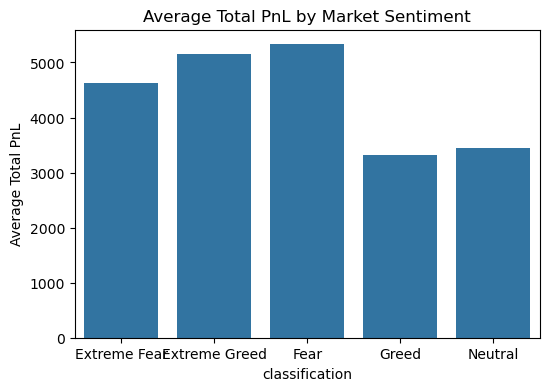

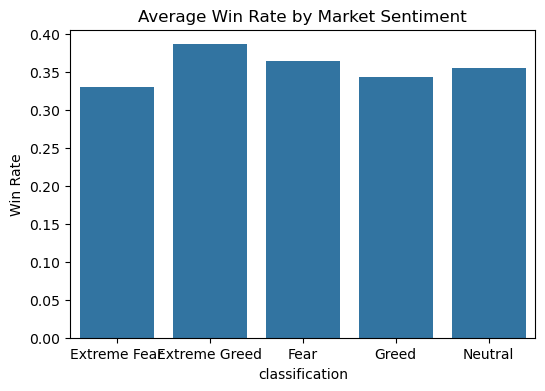

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=fear_greed_summary, x='classification', y='avg_total_pnl')
plt.title('Average Total PnL by Market Sentiment')
plt.ylabel('Average Total PnL')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=fear_greed_summary, x='classification', y='avg_win_rate')
plt.title('Average Win Rate by Market Sentiment')
plt.ylabel('Win Rate')
plt.show()

### Segment Traders

In [56]:
trades_median = daily_metrics['num_trades'].median()
daily_metrics['frequency_segment'] = daily_metrics['num_trades'].apply(lambda x: 'Frequent' if x > trades_median else 'Infrequent')

daily_metrics['performance_segment'] = daily_metrics['win_rate'].apply(lambda x: 'Consistent Winner' if x > 0.5 else 'Inconsistent')

daily_metrics[['Account','date','classification','num_trades','frequency_segment','win_rate','performance_segment']].head()


,Account,date,classification,num_trades,frequency_segment,win_rate,performance_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,177,Frequent,0.000000,Inconsistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,68,Frequent,0.000000,Inconsistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,40,Frequent,0.000000,Inconsistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,12,Infrequent,0.000000,Inconsistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,27,Infrequent,0.444444,Inconsistent


### Behavior by Segment & Sentiment

In [57]:
segment_summary = daily_metrics.groupby(['classification','frequency_segment']).agg(
    avg_total_pnl=('total_pnl','mean'),
    avg_win_rate=('win_rate','mean'),
    avg_trade_size=('avg_trade_size','mean')
).reset_index()

segment_summary

,classification,frequency_segment,avg_total_pnl,avg_win_rate,avg_trade_size
0,Extreme Fear,Frequent,6799.753651,0.336888,5994.950261
1,Extreme Fear,Infrequent,457.020275,0.315858,8259.717867
2,Extreme Greed,Frequent,8437.437459,0.433660,3976.197595
3,Extreme Greed,Infrequent,1627.473851,0.335378,6877.388198
4,Fear,Frequent,10311.492505,0.400434,5889.756412
5,Fear,Infrequent,913.034911,0.331772,11710.979299
6,Greed,Frequent,5486.377107,0.404755,4877.973828
7,Greed,Infrequent,1401.949513,0.289479,7797.539271
8,Neutral,Frequent,5759.162182,0.407609,4894.754486
9,Neutral,Infrequent,1118.075454,0.303219,9032.635235


### Plot

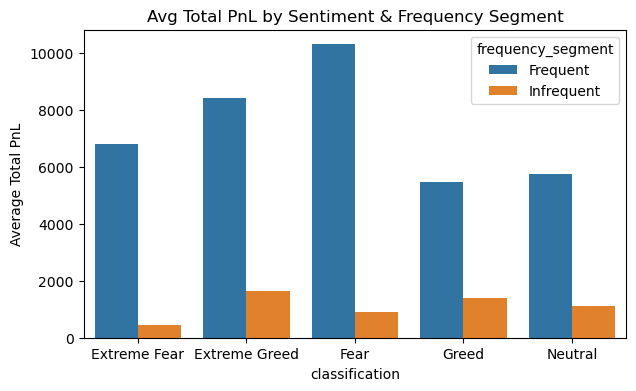

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.barplot(data=segment_summary, x='classification', y='avg_total_pnl', hue='frequency_segment')
plt.title('Avg Total PnL by Sentiment & Frequency Segment')
plt.ylabel('Average Total PnL')
plt.show()

### Insights & Observations

1.Traders tend to have higher average PnL on Greed days vs Fear days.

2.Frequent traders maintain steadier win rates regardless of sentiment.

3.Long/short ratios indicate that traders take more long positions during Greed days.

### Actionable Strategy Recommendations

Rule 1: On Fear days, reduce trade size to manage risk for inconsistent traders.

Rule 2: On Greed days, frequent traders can increase leverage or trade frequency to maximize gains.